In [ ]:
import os
from google.colab import files
import zipfile

OUTDIR = "/content/figures_pdf"
os.makedirs(OUTDIR, exist_ok=True)


[RUN] T=10.0, N=100, h=0.100000, delta=4.0, delay_steps=40
>>> Training PG (Algo 1)...
  iter     1 | LSTM-DPO loss = -10.4408426282
  iter   200 | LSTM-DPO loss = -10.8396279075
  iter   400 | LSTM-DPO loss = -10.8418826252
  iter   600 | LSTM-DPO loss = -10.9515329065
  iter   800 | LSTM-DPO loss = -10.9450257910
  iter  1000 | LSTM-DPO loss = -10.9638673439
  iter  1200 | LSTM-DPO loss = -10.8758050363
  iter  1400 | LSTM-DPO loss = -10.9936555854
  iter  1600 | LSTM-DPO loss = -10.9775200894
  iter  1800 | LSTM-DPO loss = -10.9921507897
  iter  2000 | LSTM-DPO loss = -10.8671575769
>>> Computing PGDPO (Algo 2)...
>>> Training FABSDE (Algo 3)...
  iter     1 | FABSDE loss = 14.5258742406
  iter   500 | FABSDE loss = 0.0268423946
  iter  1000 | FABSDE loss = 0.0119759643
  iter  1500 | FABSDE loss = 0.0092594888
  iter  2000 | FABSDE loss = 0.0081504707
  iter  2500 | FABSDE loss = 0.0075065636
  iter  3000 | FABSDE loss = 0.0069913258
  iter  3500 | FABSDE loss = 0.0066335312
  ite

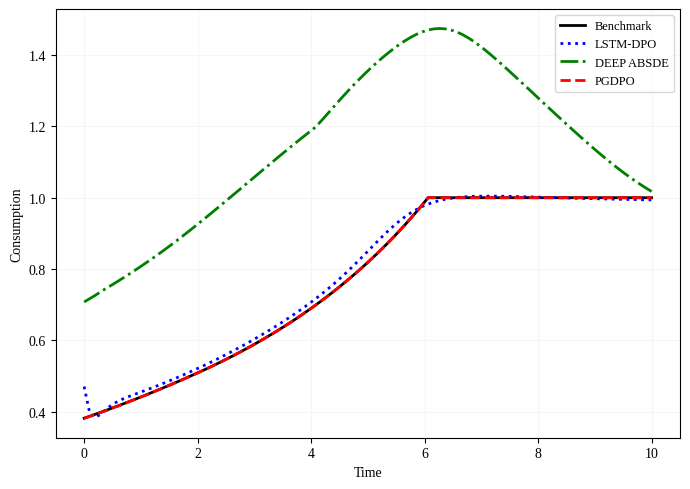


[RUN] T=30.0, N=300, h=0.100000, delta=12.0, delay_steps=120
>>> Training PG (Algo 1)...
  iter     1 | LSTM-DPO loss = -23.3367660928
  iter   200 | LSTM-DPO loss = -27.6188863006
  iter   400 | LSTM-DPO loss = -27.8457287179
  iter   600 | LSTM-DPO loss = -27.8331016109
  iter   800 | LSTM-DPO loss = -28.0253984014
  iter  1000 | LSTM-DPO loss = -27.8797465551
  iter  1200 | LSTM-DPO loss = -27.8645094882
  iter  1400 | LSTM-DPO loss = -27.9321223020
  iter  1600 | LSTM-DPO loss = -27.8956211253
  iter  1800 | LSTM-DPO loss = -28.0768618175
  iter  2000 | LSTM-DPO loss = -27.6168891236
>>> Computing PGDPO (Algo 2)...
>>> Training FABSDE (Algo 3)...
  iter     1 | FABSDE loss = 96.2445861381
  iter   500 | FABSDE loss = 0.0708704920
  iter  1000 | FABSDE loss = 0.0420479150
  iter  1500 | FABSDE loss = 0.0303422001
  iter  2000 | FABSDE loss = 0.0238126731
  iter  2500 | FABSDE loss = 0.0206347572
  iter  3000 | FABSDE loss = 0.0194660687
  iter  3500 | FABSDE loss = 0.0182224076
  i

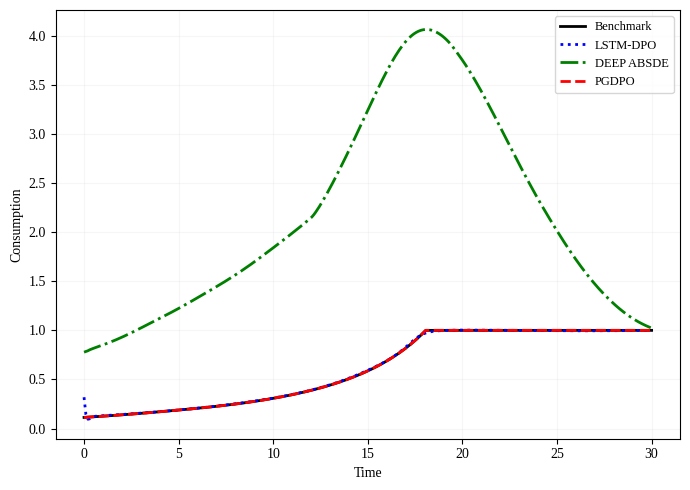


######################################################################################################################################################
Summary Table
######################################################################################################################################################
     T |     N |        h |    delta | delay_steps |  PG train(s) |  PGDPO total(s) |  PGDPO max/step(s) | FABSDE train(s) |    PG RMSE |   PGDPO RMSE |  FABSDE RMSE |     PG MAE |    PGDPO MAE |   FABSDE MAE
----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
  10.0 |   100 |    0.100 |    4.000 |          40 |   377.092000 |        7.939309 |           0.167528 |     2371.399611 | 1.674433e-02 | 1.804156e-04 | 4.033841e-01 | 1.215656e-02 | 1.011489e-04 | 3.779786e-01
  30.0 |   300 |    0.100 |   12.000 |         120 |

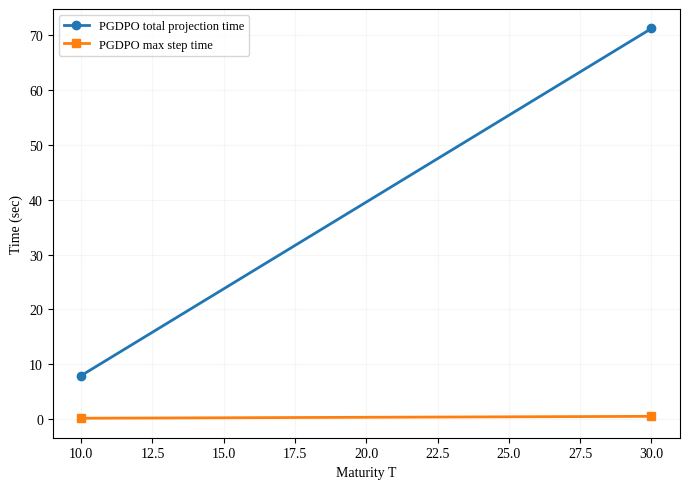

[ZIP saved] /content/figures_pdf.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import time
import copy
import math
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

plt.rcParams.update({
    "pdf.fonttype": 42,
    "font.family": "serif",
    "font.serif": ["Liberation Serif", "FreeSerif", "serif"],
    "font.size": 10,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "mathtext.fontset": "stix",
})

# =============================================================================
# 0. Base Configuration
# =============================================================================
BASE_CFG = {
    # reproducibility / device / dtype
    "seed": 42,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "dtype": torch.float64,

    # problem params
    "alpha": 0.1,
    "beta": 0.2,
    "gamma": 0.5,
    "k_terminal": 1.0,
    "T": 1.0,          # overwritten in sweep
    "N": 10,           # overwritten by N = 10*T
    "delta": 0.4,      # default; can overwrite below if you want delta = 0.3*T
    "X0": 1.0,

    # training params
    "train_paths": 256,
    "hidden": 64,
    "lr": 3e-4,

    # iterations
    "n_iters": 2000,
    "fabsde_iters": 10000,

    # PGDPO projection
    "proj_rollouts": 8192,

    # logging
    "pg_print_every": 200,
    "fabsde_print_every": 500,
}

# -----------------------------------------------------------------------------
# IMPORTANT SWITCH
# -----------------------------------------------------------------------------
# False: user’s first sentence 기준 -> N = 10*T, so h = 0.1 fixed
# True : if what you really meant was delta = 0.3*T
USE_DELTA_EQUAL_03T = True


# =============================================================================
# 1. Utilities
# =============================================================================
def set_seed(seed: int) -> None:
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def get_device_and_dtype(cfg: dict):
    device = torch.device(cfg["device"])
    dtype = cfg["dtype"]
    torch.set_default_dtype(dtype)
    return device, dtype


# =============================================================================
# 2. Physics
# =============================================================================
class Physics:
    def __init__(self, cfg: dict, device: torch.device):
        self.alpha = float(cfg["alpha"])
        self.beta = float(cfg["beta"])
        self.gamma = float(cfg["gamma"])
        self.k_term = float(cfg["k_terminal"])

        self.T = float(cfg["T"])
        self.N = int(cfg["N"])
        self.h = self.T / self.N

        self.delta = float(cfg["delta"])
        self.delay_steps = int(round(self.delta / self.h))
        self.device = device

    def step(self, x_now, x_lag, u, dW):
        drift = self.alpha * x_lag - u
        diff = self.beta * x_lag
        return x_now + drift * self.h + diff * dW

    def utility(self, u):
        return (u ** self.gamma) / self.gamma

    def get_terminal_reward(self, x_final):
        return self.k_term * x_final

    def init_history(self, batch_size: int, x0: float):
        return [
            torch.full((batch_size,), x0, device=self.device)
            for _ in range(self.delay_steps + 1)
        ]


# =============================================================================
# 3. Models
# =============================================================================
class BaseLSTM(nn.Module):
    def __init__(self, output_dim: int, hidden_dim: int):
        super().__init__()
        self.lstm = nn.LSTM(input_size=3, hidden_size=hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, t, x, x_lag, hidden):
        inp = torch.stack([t, x, x_lag], dim=1).unsqueeze(1)  # (B, 1, 3)
        out, new_hidden = self.lstm(inp, hidden)
        return self.fc(out[:, -1, :]), new_hidden


class PolicyNet(nn.Module):
    """
    LSTM-DPO / PGDPO policy without explicit x_lag input.

    Policy input:
        (t, x_now)

    Dynamics still uses x_lag through phy.step(...).
    """
    def __init__(self, hidden_dim: int):
        super().__init__()
        self.lstm = nn.LSTM(input_size=2, hidden_size=hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, t, x, hidden):
        inp = torch.stack([t, x], dim=1).unsqueeze(1)  # (B, 1, 2)
        out, h_new = self.lstm(inp, hidden)
        raw = self.fc(out[:, -1, :])
        c = torch.nn.functional.softplus(raw).squeeze(-1)
        return c, h_new


class FABSDE_Net(BaseLSTM):
    def __init__(self, hidden_dim: int):
        super().__init__(output_dim=4, hidden_dim=hidden_dim)  # Y, Z, EY, EZ

    def forward(self, t, x, x_lag, hidden):
        raw, new_hidden = super().forward(t, x, x_lag, hidden)
        Y = torch.nn.functional.softplus(raw[:, 0]) + 1e-6
        Z = raw[:, 1]
        EY = torch.nn.functional.softplus(raw[:, 2]) + 1e-6
        EZ = raw[:, 3]
        return Y, Z, EY, EZ, new_hidden


# =============================================================================
# 4. Analytic benchmark
# =============================================================================
def solve_analytic(cfg: dict):
    phy = Physics(cfg, device=torch.device(cfg["device"]))
    N = int(cfg["N"])
    p = np.zeros(N + 1, dtype=np.float64)

    start_idx = max(N - phy.delay_steps, 0)
    p[start_idx:] = cfg["k_terminal"]

    for i in range(start_idx - 1, -1, -1):
        future_idx = i + 1 + phy.delay_steps
        if future_idx <= N:
            p[i] = p[i + 1] + cfg["alpha"] * phy.h * p[future_idx]
        else:
            p[i] = p[i + 1]

    c_star = np.maximum(p, 1e-12) ** (1.0 / (cfg["gamma"] - 1.0))
    return c_star, p


# =============================================================================
# 5. Stage I: PG / LSTM-DPO
# =============================================================================
def train_pg(policy: nn.Module, phy: Physics, cfg: dict):
    print(">>> Training PG (Algo 1)...")
    opt = optim.Adam(policy.parameters(), lr=cfg["lr"])

    for it in range(1, cfg["n_iters"] + 1):
        opt.zero_grad()

        dW = torch.randn(cfg["train_paths"], cfg["N"], device=phy.device) * np.sqrt(phy.h)
        X = torch.zeros(cfg["train_paths"], cfg["N"] + phy.delay_steps + 1, device=phy.device)
        X[:, : phy.delay_steps + 1] = cfg["X0"]

        run_util = 0.0
        hidden = None

        for n in range(cfg["N"]):
            k = phy.delay_steps + n
            t_val = torch.full((cfg["train_paths"],), n * phy.h, device=phy.device)

            x_now = X[:, k]
            x_lag = X[:, n]

            # Policy receives only current state x_now.
            c_n, hidden = policy(t_val, x_now, hidden)

            # Dynamics still uses x_lag.
            X[:, k + 1] = phy.step(x_now, x_lag, c_n, dW[:, n])
            run_util = run_util + phy.utility(c_n) * phy.h

        loss = -(run_util + phy.get_terminal_reward(X[:, -1])).mean()

        if it == 1 or it % cfg["pg_print_every"] == 0 or it == cfg["n_iters"]:
            print(f"  iter {it:5d} | LSTM-DPO loss = {loss.item():.10f}")

        loss.backward()
        opt.step()

    return policy


@torch.no_grad()
@torch.no_grad()
def eval_pg_policy(policy: nn.Module, phy: Physics, cfg: dict):
    c_pg = []
    hidden = None
    X = phy.init_history(1, cfg["X0"])

    for i in range(cfg["N"]):
        k = phy.delay_steps + i
        t_i = torch.tensor([i * phy.h], device=phy.device)

        x_now = X[k]
        x_lag = X[i]

        # Policy receives only current state x_now.
        c_i, hidden = policy(t_i, x_now, hidden)
        c_pg.append(float(c_i.item()))

        # Dynamics still uses x_lag.
        x_next = phy.step(x_now, x_lag, c_i, 0.0)
        X.append(x_next)

    return np.array(c_pg, dtype=np.float64)

def sample_antithetic_dW(batch_size: int, h: float, device: torch.device):
    """
    Antithetic Brownian increments with shape (batch_size,).

    If batch_size is even:
        [eps_1, ..., eps_m, -eps_1, ..., -eps_m]

    If batch_size is odd:
        one extra independent draw is appended.
    """
    half = batch_size // 2
    scale = np.sqrt(h)

    eps_half = torch.randn(half, device=device) * scale
    dW = torch.cat([eps_half, -eps_half], dim=0)

    if batch_size % 2 == 1:
        extra = torch.randn(1, device=device) * scale
        dW = torch.cat([dW, extra], dim=0)

    return dW
# =============================================================================
# 6. Stage II: PGDPO with timing
# =============================================================================
def compute_ppgdpo_with_timing(base_policy: nn.Module, phy: Physics, cfg: dict):
    print(">>> Computing PGDPO (Algo 2)...")
    c_proj, p_proj = [], []
    step_times = []

    # deterministic realized state history
    real_hist = [torch.tensor([cfg["X0"]], device=phy.device) for _ in range(phy.delay_steps + 1)]

    # real_hidden_hist[i] = hidden state available at the beginning of decision step i
    real_hidden_hist = [None]

    def _clone_hidden(hidden):
        if hidden is None:
            return None
        h, c = hidden
        return (h.detach().clone(), c.detach().clone())

    def _expand_hidden(hidden, batch_size: int):
        if hidden is None:
            return None
        h, c = hidden
        h = h.expand(-1, batch_size, -1).contiguous()
        c = c.expand(-1, batch_size, -1).contiguous()
        return (h, c)

    hidden_real = None
    total_t0 = time.time()

    for i in range(cfg["N"]):
        step_t0 = time.time()

        x_start = real_hist[-1].detach().clone().requires_grad_(True)
        n_inner = int(cfg["proj_rollouts"])

        # stored hidden for current decision step i
        hidden_prefix = real_hidden_hist[i]
        hidden_inner = _expand_hidden(hidden_prefix, n_inner)

        if phy.delay_steps > 0:
            past_hist = torch.stack(real_hist[:-1]).detach()
            past_hist = past_hist[-phy.delay_steps:]              # (delay_steps, 1)
            past_hist = past_hist.expand(-1, n_inner)             # (delay_steps, n_inner)
            curr_state = x_start.expand(n_inner)
            inner_X = [past_hist[k] for k in range(phy.delay_steps)] + [curr_state]
        else:
            inner_X = [x_start.expand(n_inner)]

        J_future = 0.0

        for step in range(cfg["N"] - i):
            abs_step = i + step
            k_idx = phy.delay_steps + step
            t_val = torch.full((n_inner,), abs_step * phy.h, device=phy.device)

            x_now = inner_X[k_idx]
            x_lag = inner_X[step]

            # Policy receives only current state x_now.
            c_val, hidden_inner = base_policy(t_val, x_now, hidden_inner)

            # Dynamics still uses x_lag, with antithetic Brownian increments.
            dW = sample_antithetic_dW(n_inner, phy.h, device=phy.device)
            x_next = phy.step(x_now, x_lag, c_val, dW)

            inner_X.append(x_next)
            J_future = J_future + phy.utility(c_val) * phy.h

        J_total = J_future + phy.get_terminal_reward(inner_X[-1])
        grad_x = torch.autograd.grad(
            J_total.sum(),
            x_start,
            retain_graph=False,
            create_graph=False,
        )[0]
        p_t = float(grad_x.item()) / n_inner

        p_clamped = max(p_t, 1e-12)
        c_star = float(p_clamped ** (1.0 / (cfg["gamma"] - 1.0)))

        c_proj.append(c_star)
        p_proj.append(p_t)

        if phy.delay_steps > 0:
            x_lag_real = real_hist[-(phy.delay_steps + 1)]
        else:
            x_lag_real = real_hist[-1]

        # update hidden history along the realized input stream
        t_real = torch.tensor([i * phy.h], device=phy.device)
        with torch.no_grad():
            # Hidden state is updated using only current state.
            _, hidden_real = base_policy(t_real, real_hist[-1], hidden_real)

        x_next_real = phy.step(
            real_hist[-1],
            x_lag_real,
            torch.tensor([c_star], device=phy.device),
            0.0,
        )
        real_hist.append(x_next_real.detach())
        real_hidden_hist.append(_clone_hidden(hidden_real))

        step_times.append(time.time() - step_t0)

    total_elapsed = time.time() - total_t0
    avg_step_elapsed = float(np.mean(step_times)) if len(step_times) > 0 else np.nan

    return (
        np.array(c_proj, dtype=np.float64),
        np.array(p_proj, dtype=np.float64),
        float(total_elapsed),
        float(avg_step_elapsed),
        np.array(step_times, dtype=np.float64),
    )

# =============================================================================
# 7. FABSDE
# =============================================================================
def train_fabsde(phy: Physics, cfg: dict):
    print(">>> Training FABSDE (Algo 3)...")
    net = FABSDE_Net(hidden_dim=cfg["hidden"]).to(phy.device)
    opt = optim.Adam(net.parameters(), lr=cfg["lr"])

    for it in range(1, cfg["fabsde_iters"] + 1):
        opt.zero_grad()

        B = cfg["train_paths"]
        dW = torch.randn(B, cfg["N"], device=phy.device) * np.sqrt(phy.h)
        X = phy.init_history(B, cfg["X0"])

        preds = {"Y": [], "Z": [], "EY": [], "EZ": []}
        tildeY = [None] * (cfg["N"] + 1)
        hidden = None

        for i in range(cfg["N"]):
            k = phy.delay_steps + i
            t_i = torch.full((B,), i * phy.h, device=phy.device)

            Y, Z, EY, EZ, hidden = net(t_i, X[k], X[i], hidden)
            preds["Y"].append(Y)
            preds["Z"].append(Z)
            preds["EY"].append(EY)
            preds["EZ"].append(EZ)

            c_i = Y.pow(1.0 / (cfg["gamma"] - 1.0))
            X.append(phy.step(X[k], X[i], c_i, dW[:, i]))

            if i <= cfg["N"] - phy.delay_steps:
                f_i = cfg["alpha"] * EY + cfg["beta"] * EZ
            else:
                f_i = torch.zeros_like(Y)

            tildeY[i + 1] = Y - f_i * phy.h + Z * dW[:, i]

        t_N = torch.full((B,), cfg["N"] * phy.h, device=phy.device)
        Y_N, Z_N, EY_N, EZ_N, _ = net(t_N, X[-1], X[cfg["N"]], hidden)
        preds["Y"].append(Y_N)
        preds["Z"].append(Z_N)
        preds["EY"].append(EY_N)
        preds["EZ"].append(EZ_N)

        L1 = sum((preds["Y"][i + 1] - tildeY[i + 1]).pow(2).mean() for i in range(cfg["N"]))
        L1 = L1 + (preds["Y"][cfg["N"]] - cfg["k_terminal"]).pow(2).mean()

        L2 = 0.0
        if phy.delay_steps <= cfg["N"]:
            limit = cfg["N"] - phy.delay_steps
            L2 = L2 + sum((preds["EY"][i] - tildeY[i + phy.delay_steps]).pow(2).mean() for i in range(limit + 1))
            L2 = L2 + sum((preds["EZ"][i] - preds["Z"][i + phy.delay_steps]).pow(2).mean() for i in range(limit + 1))

        loss = L1 + L2
        loss.backward()
        opt.step()

        if it == 1 or it % cfg["fabsde_print_every"] == 0 or it == cfg["fabsde_iters"]:
            print(f"  iter {it:5d} | FABSDE loss = {loss.item():.10f}")

    with torch.no_grad():
        c_path, Y_path = [], []
        hidden = None
        X = phy.init_history(1, cfg["X0"])

        for i in range(cfg["N"]):
            k = phy.delay_steps + i
            t_val = torch.tensor([i * phy.h], device=phy.device)
            res = net(t_val, X[k], X[i], hidden)
            hidden = res[-1]
            c_val = res[0].pow(1.0 / (cfg["gamma"] - 1.0))
            c_path.append(c_val.item())
            Y_path.append(res[0].item())
            X.append(phy.step(X[k], X[i], c_val, 0.0))

    return np.array(c_path, dtype=np.float64), np.array(Y_path, dtype=np.float64)


# =============================================================================
# 8. Metrics / Plotting
# =============================================================================
def compute_rmse_mae(gt: np.ndarray, pred: np.ndarray):
    L = min(len(gt), len(pred))
    err = pred[:L] - gt[:L]
    rmse = float(np.sqrt(np.mean(err ** 2)))
    mae = float(np.mean(np.abs(err)))
    return rmse, mae


def print_metrics(gt: np.ndarray, preds: dict):
    print(f"\n{'Algorithm':<15} | {'RMSE':<12} | {'MAE':<12}")
    print("-" * 46)
    for name, pred in preds.items():
        rmse, mae = compute_rmse_mae(gt, pred)
        print(f"{name:<15} | {rmse:<12.8f} | {mae:<12.8f}")


def plot_controls(t_grid: np.ndarray, gt: np.ndarray, c_pg, c_fabsde, c_proj, title: str, save_path: str = None,):
    #plt.figure(figsize=(7, 5))
    fig, ax = plt.subplots(figsize=(7, 5))
    plt.plot(t_grid, gt, "k-", lw=2, label="Benchmark")
    plt.plot(t_grid, c_pg, "b:", lw=2, label="LSTM-DPO")
    plt.plot(t_grid, c_fabsde, "g-.", lw=2, label="DEEP ABSDE")
    plt.plot(t_grid, c_proj, "r--", lw=2, label="PGDPO")
    plt.xlabel("Time")
    plt.ylabel("Consumption")
    #plt.title(title)
    plt.legend()
    plt.grid(alpha=0.1)
    plt.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, format="pdf", bbox_inches="tight")
        print(f"[Saved] {save_path}")
    plt.show()
    plt.close(fig)


# =============================================================================
# 9. Config builder for maturity sweep
# =============================================================================
def build_cfg_for_T(T_value: float, base_cfg: dict):
    cfg = copy.deepcopy(base_cfg)
    cfg["T"] = float(T_value)

    # User request:
    # T=1 -> 10 steps, T=5 -> 50 steps, ...
    # Therefore N = 10*T and h = T/N = 0.1
    cfg["N"] = int(round(10 * T_value))

    if USE_DELTA_EQUAL_03T:
        cfg["delta"] = 0.4 * T_value

    return cfg


# =============================================================================
# 10. One maturity run
# =============================================================================
def run_one_maturity(T_value: float, base_cfg: dict):
    cfg = build_cfg_for_T(T_value, base_cfg)

    set_seed(cfg["seed"])
    device, _ = get_device_and_dtype(cfg)
    phy = Physics(cfg, device=device)

    print("\n" + "=" * 110)
    print(
        f"[RUN] T={cfg['T']}, N={cfg['N']}, h={phy.h:.6f}, "
        f"delta={cfg['delta']}, delay_steps={phy.delay_steps}"
    )
    print("=" * 110)

    # 1) Analytic benchmark
    c_ana, _ = solve_analytic(cfg)
    gt = c_ana[:-1]

    # 2) Stage I: PG / LSTM-DPO
    t0_pg = time.time()
    policy_pg = train_pg(PolicyNet(hidden_dim=cfg["hidden"]).to(device), phy, cfg)
    pg_train_time = time.time() - t0_pg
    c_pg = eval_pg_policy(policy_pg, phy, cfg)

    # 3) Stage II: PGDPO + timing
    c_proj, p_proj, proj_total_time, proj_avg_step_time, proj_step_times = compute_ppgdpo_with_timing(
        policy_pg, phy, cfg
    )

    # 4) FABSDE
    t0_fabsde = time.time()
    c_fabsde, y_fabsde = train_fabsde(phy, cfg)
    fabsde_train_time = time.time() - t0_fabsde

    preds = {
        "PG": c_pg,
        "PGDPO": c_proj,
        "FABSDE": c_fabsde,
    }
    print_metrics(gt, preds)

    pg_rmse, pg_mae = compute_rmse_mae(gt, c_pg)
    pgdpo_rmse, pgdpo_mae = compute_rmse_mae(gt, c_proj)
    fabsde_rmse, fabsde_mae = compute_rmse_mae(gt, c_fabsde)

    print("\n[Timing]")
    print(f"PG training time (sec)            : {pg_train_time:.6f}")
    print(f"PGDPO projection total time (sec) : {proj_total_time:.6f}")
    print(f"PGDPO projection max/step (sec)   : {proj_step_times.max():.6f}")
    print(f"FABSDE training time (sec)        : {fabsde_train_time:.6f}")

    t_grid = np.linspace(0.0, cfg["T"], cfg["N"])

    fig_path = os.path.join(
        OUTDIR,
        f"controls_T{cfg['T']:.1f}_N{cfg['N']}_delta{cfg['delta']:.2f}.pdf"
    )

    plot_controls(
        t_grid, gt, c_pg, c_fabsde, c_proj,
        title=f"Benchmark 1 | T={cfg['T']}, N={cfg['N']}, h={phy.h:.3f}, delay_steps={phy.delay_steps}", save_path=fig_path,
    )

    return {
        "T": cfg["T"],
        "N": cfg["N"],
        "h": phy.h,
        "delta": cfg["delta"],
        "delay_steps": phy.delay_steps,
        "pg_train_time_sec": float(pg_train_time),
        "pgdpo_total_projection_sec": float(proj_total_time),
        "pgdpo_avg_step_sec": float(proj_avg_step_time),
        "pgdpo_min_step_sec": float(np.min(proj_step_times)),
        "pgdpo_max_step_sec": float(np.max(proj_step_times)),
        "fabsde_train_time_sec": float(fabsde_train_time),
        "pg_rmse": pg_rmse,
        "pg_mae": pg_mae,
        "pgdpo_rmse": pgdpo_rmse,
        "pgdpo_mae": pgdpo_mae,
        "fabsde_rmse": fabsde_rmse,
        "fabsde_mae": fabsde_mae,
        "gt": gt,
        "c_pg": c_pg,
        "c_proj": c_proj,
        "c_fabsde": c_fabsde,
        "p_proj": p_proj,
        "y_fabsde": y_fabsde,
        "proj_step_times": proj_step_times,
    }


# =============================================================================
# 11. Sweep over maturities
# =============================================================================
def run_maturity_sweep():
    T_list = [10.0, 30.0]
    results = []

    for Tval in T_list:
        out = run_one_maturity(Tval, BASE_CFG)
        results.append(out)

    print("\n" + "#" * 150)
    print("Summary Table")
    print("#" * 150)

    header = (
        f"{'T':>6} | {'N':>5} | {'h':>8} | {'delta':>8} | {'delay_steps':>11} | "
        f"{'PG train(s)':>12} | {'PGDPO total(s)':>15} | {'PGDPO max/step(s)':>18} | {'FABSDE train(s)':>15} | "
        f"{'PG RMSE':>10} | {'PGDPO RMSE':>12} | {'FABSDE RMSE':>12} | "
        f"{'PG MAE':>10} | {'PGDPO MAE':>12} | {'FABSDE MAE':>12}"
    )
    print(header)
    print("-" * len(header))

    for r in results:
        print(
            f"{r['T']:6.1f} | "
            f"{r['N']:5d} | "
            f"{r['h']:8.3f} | "
            f"{r['delta']:8.3f} | "
            f"{r['delay_steps']:11d} | "
            f"{r['pg_train_time_sec']:12.6f} | "
            f"{r['pgdpo_total_projection_sec']:15.6f} | "
            f"{r['pgdpo_max_step_sec']:18.6f} | "
            f"{r['fabsde_train_time_sec']:15.6f} | "
            f"{r['pg_rmse']:10.6e} | "
            f"{r['pgdpo_rmse']:12.6e} | "
            f"{r['fabsde_rmse']:12.6e} | "
            f"{r['pg_mae']:10.6e} | "
            f"{r['pgdpo_mae']:12.6e} | "
            f"{r['fabsde_mae']:12.6e}"
        )

    Ts = [r["T"] for r in results]
    proj_total = [r["pgdpo_total_projection_sec"] for r in results]
    proj_max = [r["pgdpo_max_step_sec"] for r in results]

    plt.figure(figsize=(7, 5))
    plt.plot(Ts, proj_total, marker="o", lw=2, label="PGDPO total projection time")
    plt.plot(Ts, proj_max, marker="s", lw=2, label="PGDPO max step time")
    plt.xlabel("Maturity T")
    plt.ylabel("Time (sec)")
    #plt.title("PGDPO Projection Time vs Maturity")
    plt.legend()
    plt.grid(alpha=0.1)
    plt.tight_layout()
    plt.show()


    return results


# =============================================================================
# 12. Execute
# =============================================================================
if __name__ == "__main__":
    all_results = run_maturity_sweep()

    zip_path = "/content/figures_pdf.zip"

    with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zipf:
        for fname in os.listdir(OUTDIR):
            if fname.endswith(".pdf"):
                full_path = os.path.join(OUTDIR, fname)
                zipf.write(full_path, arcname=fname)

    print(f"[ZIP saved] {zip_path}")
    files.download(zip_path)

In [ ]:
zip_path = "/content/figures_pdf.zip"

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zipf:
    for fname in os.listdir(OUTDIR):
        if fname.endswith(".pdf"):
            full_path = os.path.join(OUTDIR, fname)
            zipf.write(full_path, arcname=fname)

print(f"[ZIP saved] {zip_path}")
files.download(zip_path)

[ZIP saved] /content/figures_pdf.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


##########################################################################################
Running experiment for T=1.0 | N_steps=10 | dt=0.1000
##########################################################################################

[Warm-up] T=1.0, N_steps=10, dt=0.1000
  Iter  500 | J = 10.982521
  Iter 1000 | J = 9.267696
  Iter 1500 | J = 8.868174
  Iter 2000 | J = 8.772230
  Iter 2500 | J = 8.692452
  Iter 3000 | J = 8.708786
  Iter 3500 | J = 8.727753
  Iter 4000 | J = 8.720057
  Iter 4500 | J = 8.743965
  Iter 5000 | J = 8.729273
[T=1.0] Warm-up time          : 80.500112 sec
[T=1.0] Projection total time : 0.085528 sec
[T=1.0] Projection max/step   : 0.020188 sec
[T=1.0] LSTM-DPO   RMSE/MAE   : 3.119877 / 2.274841
[T=1.0] PGDPO      RMSE/MAE   : 0.901372 / 0.271966

##########################################################################################
Running experiment for T=10.0 | N_steps=100 | dt=0.1000
################################################################

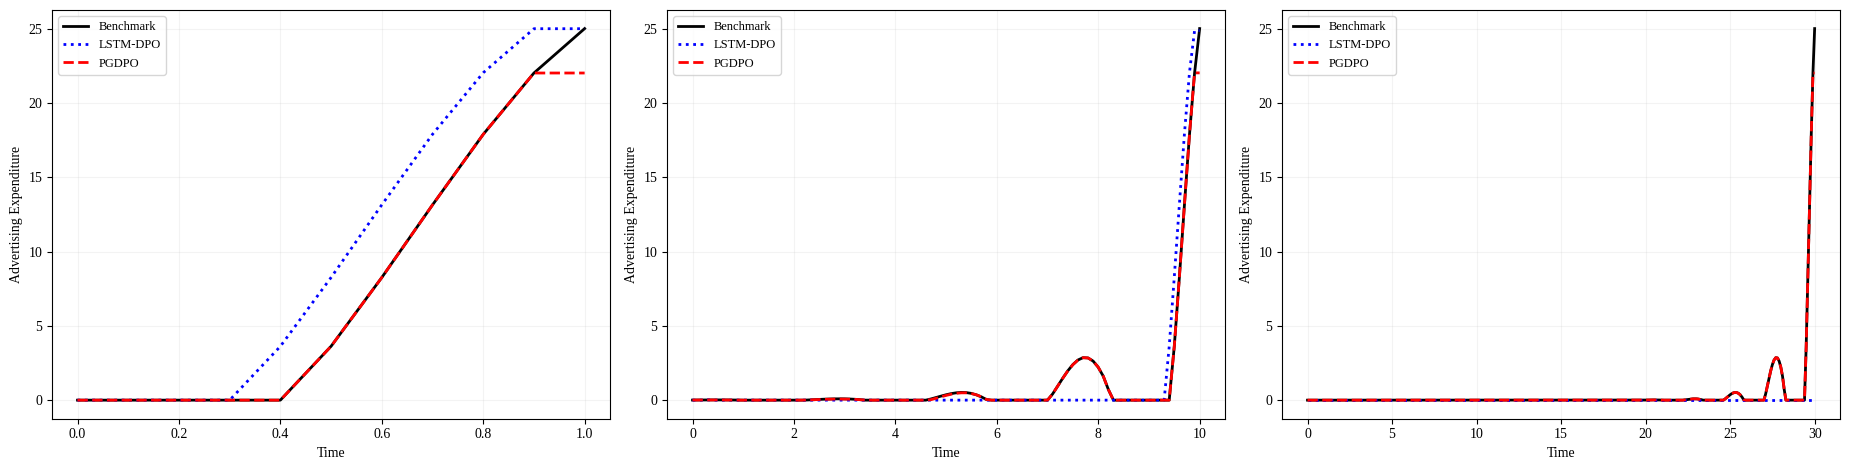

In [ ]:
import math
import time
import copy
import random
from typing import Dict, Any, Tuple, List

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

import matplotlib.pyplot as plt


# =============================================================================
# 0. Matplotlib style
# =============================================================================
plt.rcParams.update({
    "pdf.fonttype": 42,
    "font.family": "serif",
    "font.serif": ["Liberation Serif", "FreeSerif", "serif"],
    "font.size": 10,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "mathtext.fontset": "stix",
})


# =============================================================================
# 1. Unified Configuration
# =============================================================================
CFG: Dict[str, Any] = {
    # reproducibility / device / dtype
    "seed": 42,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "dtype": torch.float32,

    # dynamics / cost (advertising)
    "a0": -0.5,
    "b0": 1.0,
    "sigma": 0.2,
    "R": 0.1,
    "S0": -5.0,

    # -------------------------------------------------------------------------
    # Baseline time-grid setting in the original code:
    # T=10, N_steps=100  -> baseline dt = 0.1
    #
    # We keep the SAME dt for T=1, 10, 50 so that maturity comparison is fair.
    # Therefore:
    #   T=1  -> N_steps=10
    #   T=10 -> N_steps=100
    #   T=50 -> N_steps=500
    # -------------------------------------------------------------------------
    "T": 10.0,
    "N_steps": 100,
    "T_list": [1.0, 10.0, 30.0],
    "keep_dt_fixed_across_T": True,

    # distributed delay kernel (theta in [-delta, 0])
    "delta": 3.0,
    "H_delay": 20,
    "a1_scale": -5.0,
    "a1_lambda": 1.0,

    # initial history
    "x0": 10.0,
    "x_hist_const": 10.0,

    # -----------------------------
    # Method 1: LSTM-DPO warm-up
    # -----------------------------
    "warmup_batch_size": 512,
    "warmup_iters": 5000,
    "lr_pg": 3e-4,

    # -----------------------------
    # Stage 2 projection
    # -----------------------------
    "N_mc_stage2": 1000,

    # plotting / saving
    "save_fig": False,
    "fig_path": "maturity_comparison_controls.png",
}

DEVICE = torch.device(CFG["device"])
torch.set_default_dtype(CFG["dtype"])


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def get_dt(cfg: Dict[str, Any]) -> float:
    return float(cfg["T"]) / float(cfg["N_steps"])


def make_cfg_for_T(base_cfg: Dict[str, Any], T_new: float) -> Dict[str, Any]:
    cfg = copy.deepcopy(base_cfg)
    cfg["T"] = float(T_new)

    if bool(base_cfg.get("keep_dt_fixed_across_T", True)):
        dt_base = float(base_cfg["T"]) / int(base_cfg["N_steps"])
        n_steps = max(1, int(round(float(T_new) / dt_base)))
        cfg["N_steps"] = n_steps
    # else: keep original N_steps

    return cfg


# =============================================================================
# 2. Physics helpers
# =============================================================================
def build_a1_kernel_np(cfg: Dict[str, Any]) -> np.ndarray:
    H = int(cfg["H_delay"])
    delta = float(cfg["delta"])
    dtheta = delta / H
    theta = -delta + dtheta * (np.arange(H) + 0.5)
    a1_vals = float(cfg["a1_scale"]) * np.exp(float(cfg["a1_lambda"]) * theta)
    w = a1_vals * dtheta
    w = w[::-1].copy()
    return w.astype(np.float32)


def build_a1_kernel_torch(cfg: Dict[str, Any], device: torch.device, dtype: torch.dtype) -> torch.Tensor:
    return torch.tensor(build_a1_kernel_np(cfg), device=device, dtype=dtype)


def init_hist_torch(cfg: Dict[str, Any], batch_size: int, device: torch.device, dtype: torch.dtype) -> torch.Tensor:
    H = int(cfg["H_delay"])
    x_hist = torch.full((batch_size, H), float(cfg["x_hist_const"]), device=device, dtype=dtype)
    x_hist[:, 0] = float(cfg["x0"])
    return x_hist


def init_hist_np(cfg: Dict[str, Any]) -> np.ndarray:
    H = int(cfg["H_delay"])
    x_hist = np.full(H, float(cfg["x_hist_const"]), dtype=np.float32)
    x_hist[0] = np.float32(cfg["x0"])
    return x_hist


def delay_integral_torch(w: torch.Tensor, x_hist: torch.Tensor) -> torch.Tensor:
    return torch.sum(w * x_hist, dim=1)


def shift_hist_torch(x_hist: torch.Tensor, x_new: torch.Tensor) -> torch.Tensor:
    return torch.cat([x_new.unsqueeze(1), x_hist[:, :-1]], dim=1)


def env_step_torch(
    cfg: Dict[str, Any],
    w: torch.Tensor,
    x_hist: torch.Tensor,
    v: torch.Tensor,
    dt: float,
    stochastic: bool = True,
) -> Tuple[torch.Tensor, torch.Tensor]:
    x_curr = x_hist[:, 0]
    integ = delay_integral_torch(w, x_hist)
    drift = float(cfg["a0"]) * x_curr + integ + float(cfg["b0"]) * v

    if stochastic:
        dB = math.sqrt(dt) * torch.randn_like(x_curr)
        x_next = x_curr + drift * dt + float(cfg["sigma"]) * dB
    else:
        x_next = x_curr + drift * dt

    x_hist_next = shift_hist_torch(x_hist, x_next)
    return x_hist_next, x_next


def running_cost_torch(cfg: Dict[str, Any], v: torch.Tensor, dt: float) -> torch.Tensor:
    return float(cfg["R"]) * (v ** 2) * dt


def terminal_cost_torch(cfg: Dict[str, Any], x_T: torch.Tensor) -> torch.Tensor:
    return float(cfg["S0"]) * x_T


# =============================================================================
# 3. Method 1: LSTM-DPO warm-up
# =============================================================================
class LSTMPolicy(nn.Module):
    def __init__(self, input_size: int = 2, hidden_size: int = 64):
        super().__init__()
        self.hidden_size = hidden_size
        self.lstm = nn.LSTMCell(input_size, hidden_size)
        self.head = nn.Linear(hidden_size, 1)
        nn.init.constant_(self.head.bias, 1.0)

    def init_hidden(self, batch_size: int, device: torch.device) -> Tuple[torch.Tensor, torch.Tensor]:
        h0 = torch.zeros(batch_size, self.hidden_size, device=device)
        c0 = torch.zeros(batch_size, self.hidden_size, device=device)
        return h0, c0

    def forward_step(
        self,
        t_norm: torch.Tensor,
        x_t: torch.Tensor,
        h: torch.Tensor,
        c: torch.Tensor,
    ) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        inp = torch.stack([t_norm, x_t], dim=-1)
        h_next, c_next = self.lstm(inp, (h, c))
        v_raw = self.head(h_next).squeeze(-1)
        v = torch.relu(v_raw)
        return v, h_next, c_next


def simulate_pg_batch(
    policy: LSTMPolicy,
    cfg: Dict[str, Any],
    batch_size: int,
    detach_policy: bool = False,
    stochastic: bool = True,
) -> torch.Tensor:
    dt = get_dt(cfg)
    N = int(cfg["N_steps"])
    w = build_a1_kernel_torch(cfg, device=DEVICE, dtype=torch.float32)

    x_hist = init_hist_torch(cfg, batch_size, device=DEVICE, dtype=torch.float32)
    h, c = policy.init_hidden(batch_size, DEVICE)
    cost = torch.zeros(batch_size, device=DEVICE, dtype=torch.float32)

    for n in range(N):
        t_norm = torch.full(
            (batch_size,),
            (n * dt) / float(cfg["T"]),
            device=DEVICE,
            dtype=torch.float32,
        )
        x_curr = x_hist[:, 0]

        if detach_policy:
            with torch.no_grad():
                v, h, c = policy.forward_step(t_norm, x_curr, h, c)
        else:
            v, h, c = policy.forward_step(t_norm, x_curr, h, c)

        cost = cost + running_cost_torch(cfg, v, dt)
        x_hist, _ = env_step_torch(cfg, w, x_hist, v, dt, stochastic=stochastic)

    x_T = x_hist[:, 0]
    cost = cost + terminal_cost_torch(cfg, x_T)
    return cost.mean()


def warmup_train_pg(policy: LSTMPolicy, cfg: Dict[str, Any]) -> LSTMPolicy:
    print(f"\n[Warm-up] T={cfg['T']}, N_steps={cfg['N_steps']}, dt={get_dt(cfg):.4f}")
    policy.to(DEVICE).train()
    opt = optim.Adam(policy.parameters(), lr=float(cfg["lr_pg"]))

    for it in range(int(cfg["warmup_iters"])):
        opt.zero_grad()
        J = simulate_pg_batch(
            policy,
            cfg,
            batch_size=int(cfg["warmup_batch_size"]),
            detach_policy=False,
            stochastic=True,
        )
        J.backward()
        opt.step()

        if (it + 1) % 500 == 0:
            print(f"  Iter {it + 1:4d} | J = {J.item():.6f}")

    return policy


@torch.no_grad()
def rollout_pg_deterministic(policy: LSTMPolicy, cfg: Dict[str, Any]) -> Dict[str, List[torch.Tensor]]:
    dt = get_dt(cfg)
    N = int(cfg["N_steps"])
    w = build_a1_kernel_torch(cfg, device=DEVICE, dtype=torch.float32)

    batch_size = 1
    x_hist = init_hist_torch(cfg, batch_size, device=DEVICE, dtype=torch.float32)
    h, c = policy.init_hidden(batch_size, DEVICE)

    xs, vs, hs, cs, x_hists = [], [], [], [], []

    for n in range(N):
        t_norm = torch.full(
            (batch_size,),
            (n * dt) / float(cfg["T"]),
            device=DEVICE,
            dtype=torch.float32,
        )
        x_curr = x_hist[:, 0]

        # ------------------------------------------------------------
        # Save the PREFIX state before consuming the input at step n.
        # These are the correct initial conditions for PGDPO projection
        # starting at decision step n.
        # ------------------------------------------------------------
        xs.append(x_curr.clone())
        hs.append(h.clone())
        cs.append(c.clone())
        x_hists.append(x_hist.clone())

        # policy decision at step n
        v, h, c = policy.forward_step(t_norm, x_curr, h, c)
        vs.append(v.clone())

        # deterministic rollout update
        x_hist, _ = env_step_torch(cfg, w, x_hist, v, dt, stochastic=False)

    return {
        "xs": xs,
        "vs": vs,
        "hs": hs,
        "cs": cs,
        "x_hists": x_hists,
    }


# =============================================================================
# 4. PGDPO projection
# =============================================================================
def estimate_costate_from_step(
    policy: LSTMPolicy,
    cfg: Dict[str, Any],
    n0: int,
    x_hist0: torch.Tensor,
    h0: torch.Tensor,
    c0: torch.Tensor,
) -> torch.Tensor:
    dt = get_dt(cfg)
    N = int(cfg["N_steps"])
    M = int(cfg["N_mc_stage2"])
    w = build_a1_kernel_torch(cfg, device=DEVICE, dtype=torch.float32)

    x0_var = x_hist0[0, 0].detach().clone().requires_grad_(True)
    x_curr_batch = x0_var.expand(M)

    x_hist_rest = x_hist0[:, 1:].repeat(M, 1)
    x_hist = torch.cat([x_curr_batch.unsqueeze(1), x_hist_rest], dim=1)

    h = h0.repeat(M, 1)
    c = c0.repeat(M, 1)

    cost = torch.zeros(M, device=DEVICE, dtype=torch.float32)

    for n in range(n0, N):
        t_norm = torch.full(
            (M,),
            (n * dt) / float(cfg["T"]),
            device=DEVICE,
            dtype=torch.float32,
        )
        v, h, c = policy.forward_step(t_norm, x_hist[:, 0], h, c)
        cost = cost + running_cost_torch(cfg, v, dt)
        x_hist, _ = env_step_torch(cfg, w, x_hist, v, dt, stochastic=True)

    x_T = x_hist[:, 0]
    cost = cost + terminal_cost_torch(cfg, x_T)

    J_mean = cost.mean()
    (grad_x0,) = torch.autograd.grad(J_mean, x0_var, retain_graph=False, create_graph=False)
    return grad_x0.detach()


# =============================================================================
# 5. Analytic PMP benchmark
# =============================================================================
def analytic_pmp_solution(cfg: Dict[str, Any]) -> Tuple[np.ndarray, np.ndarray]:
    dt = get_dt(cfg)
    N = int(cfg["N_steps"])
    H = int(cfg["H_delay"])

    w = build_a1_kernel_np(cfg)

    A = np.zeros((H, H), dtype=np.float64)
    A[0, 0] = 1.0 + dt * float(cfg["a0"]) + dt * float(w[0])
    A[0, 1:] = dt * w[1:]
    for i in range(1, H):
        A[i, i - 1] = 1.0

    Y = np.zeros((N + 1, H), dtype=np.float64)
    Y[N, 0] = float(cfg["S0"])

    AT = A.T
    for n in reversed(range(N)):
        Y[n] = AT @ Y[n + 1]

    v_star = np.zeros(N + 1, dtype=np.float64)
    for n in range(N + 1):
        v_un = -(float(cfg["b0"]) / (2.0 * float(cfg["R"]))) * Y[n, 0]
        v_star[n] = max(0.0, v_un)

    t_grid = np.linspace(0.0, float(cfg["T"]), N + 1)
    return t_grid, v_star


# =============================================================================
# 6. Metrics / Plot
# =============================================================================
def compute_metrics(gt: np.ndarray, pred: np.ndarray) -> Tuple[float, float]:
    m = min(len(gt), len(pred))
    rmse = float(np.sqrt(np.mean((pred[:m] - gt[:m]) ** 2)))
    mae = float(np.mean(np.abs(pred[:m] - gt[:m])))
    return rmse, mae


def print_results_table(results: List[Dict[str, Any]]) -> None:
    print("\n" + "=" * 118)
    print(
        f"{'T':>8} | {'N_steps':>8} | {'dt':>8} | "
        f"{'LSTM RMSE':>12} | {'LSTM MAE':>12} | "
        f"{'PGDPO RMSE':>12} | {'PGDPO MAE':>12} | "
        f"{'Proj total(s)':>13} | {'Proj max/step(s)':>16}"
    )
    print("-" * 118)

    for r in results:
        print(
            f"{r['T']:8.2f} | {r['N_steps']:8d} | {r['dt']:8.4f} | "
            f"{r['rmse_lstm']:12.6f} | {r['mae_lstm']:12.6f} | "
            f"{r['rmse_pgdpo']:12.6f} | {r['mae_pgdpo']:12.6f} | "
            f"{r['projection_total_sec']:13.6f} | {r['projection_max_sec_per_step']:16.6f}"
        )

    print("=" * 118)


def plot_all_controls(results: List[Dict[str, Any]], cfg: Dict[str, Any]) -> None:
    n = len(results)
    fig, axes = plt.subplots(1, n, figsize=(6.2 * n, 4.8), squeeze=False)
    axes = axes[0]

    for ax, r in zip(axes, results):
        ax.plot(r["t_grid"], r["v_star"], "k-", lw=2, label="Benchmark")
        ax.plot(r["t_grid"], r["v_lstm"], "b:", lw=2, label="LSTM-DPO")
        ax.plot(r["t_grid"], r["v_pgdpo"], "r--", lw=2, label="PGDPO")

        #ax.set_title(
        #    f"T={r['T']}, N={r['N_steps']}\n"
        #    f"LSTM: RMSE={r['rmse_lstm']:.4f}, MAE={r['mae_lstm']:.4f}\n"
        #    f"PGDPO: RMSE={r['rmse_pgdpo']:.4f}, MAE={r['mae_pgdpo']:.4f}"
        #)
        ax.set_xlabel("Time")
        ax.set_ylabel("Advertising Expenditure")
        ax.grid(alpha=0.15)
        ax.legend()

    plt.tight_layout()
    if bool(cfg.get("save_fig", False)):
        plt.savefig(cfg["fig_path"], dpi=200, bbox_inches="tight")
        print(f"\nFigure saved to: {cfg['fig_path']}")
    plt.show()


# =============================================================================
# 7. Per-maturity experiment
# =============================================================================
def run_single_maturity_experiment(base_cfg: Dict[str, Any], T_target: float) -> Dict[str, Any]:
    cfg = make_cfg_for_T(base_cfg, T_target)
    set_seed(int(cfg["seed"]))

    print("\n" + "#" * 90)
    print(f"Running experiment for T={cfg['T']} | N_steps={cfg['N_steps']} | dt={get_dt(cfg):.4f}")
    print("#" * 90)

    # 1) Warm-up training
    policy_pg = LSTMPolicy(input_size=2, hidden_size=64)
    t_train_0 = time.time()
    policy_pg = warmup_train_pg(policy_pg, cfg)
    t_train_1 = time.time()
    warmup_sec = t_train_1 - t_train_0

    # 2) Analytic benchmark
    t_grid, v_star = analytic_pmp_solution(cfg)

    # 3) Deterministic rollout of warm-up policy
    policy_pg.eval()
    rollout = rollout_pg_deterministic(policy_pg, cfg)

    # 4) Stage-2 projection at every time step
    N = int(cfg["N_steps"])
    v_lstm = []
    v_pgdpo = []
    projection_step_times = []

    proj_start = time.time()
    for n in range(N):
        step_t0 = time.time()

        v_net = float(rollout["vs"][n].item())

        lam = estimate_costate_from_step(
            policy_pg,
            cfg,
            n,
            rollout["x_hists"][n],
            rollout["hs"][n],
            rollout["cs"][n],
        )

        v_proj = max(0.0, -(float(cfg["b0"]) / (2.0 * float(cfg["R"]))) * float(lam.item()))

        v_lstm.append(v_net)
        v_pgdpo.append(v_proj)
        projection_step_times.append(time.time() - step_t0)
    proj_end = time.time()

    projection_total_sec = proj_end - proj_start
    projection_avg_sec_per_step = projection_total_sec / max(N, 1)
    projection_max_sec_per_step = float(np.max(projection_step_times)) if len(projection_step_times) > 0 else float("nan")

    # Append one more point to match benchmark length N+1
    v_lstm.append(v_lstm[-1])
    v_pgdpo.append(v_pgdpo[-1])

    v_lstm = np.array(v_lstm, dtype=np.float64)
    v_pgdpo = np.array(v_pgdpo, dtype=np.float64)

    m = min(len(v_star), len(v_lstm), len(v_pgdpo), len(t_grid))
    t_grid = t_grid[:m]
    v_star = v_star[:m]
    v_lstm = v_lstm[:m]
    v_pgdpo = v_pgdpo[:m]

    rmse_lstm, mae_lstm = compute_metrics(v_star, v_lstm)
    rmse_pgdpo, mae_pgdpo = compute_metrics(v_star, v_pgdpo)

    print(f"[T={cfg['T']}] Warm-up time          : {warmup_sec:.6f} sec")
    print(f"[T={cfg['T']}] Projection total time : {projection_total_sec:.6f} sec")
    print(f"[T={cfg['T']}] Projection max/step   : {projection_max_sec_per_step:.6f} sec")
    print(f"[T={cfg['T']}] LSTM-DPO   RMSE/MAE   : {rmse_lstm:.6f} / {mae_lstm:.6f}")
    print(f"[T={cfg['T']}] PGDPO      RMSE/MAE   : {rmse_pgdpo:.6f} / {mae_pgdpo:.6f}")

    return {
        "T": float(cfg["T"]),
        "N_steps": int(cfg["N_steps"]),
        "dt": get_dt(cfg),
        "warmup_sec": warmup_sec,
        "projection_total_sec": projection_total_sec,
        "projection_avg_sec_per_step": projection_avg_sec_per_step,
        "projection_max_sec_per_step": projection_max_sec_per_step,
        "rmse_lstm": rmse_lstm,
        "mae_lstm": mae_lstm,
        "rmse_pgdpo": rmse_pgdpo,
        "mae_pgdpo": mae_pgdpo,
        "t_grid": t_grid,
        "v_star": v_star,
        "v_lstm": v_lstm,
        "v_pgdpo": v_pgdpo,
    }


# =============================================================================
# 8. Main
# =============================================================================
def main() -> None:
    all_results: List[Dict[str, Any]] = []

    for T_target in CFG["T_list"]:
        res = run_single_maturity_experiment(CFG, float(T_target))
        all_results.append(res)

    print_results_table(all_results)
    plot_all_controls(all_results, CFG)


if __name__ == "__main__":
    main()

# Experiment #3: Varying Delay (Problem 1)
...? 난 이게 왜중요한지 잘 모르겠음
1)Computational Cost with long delay

In [ ]:
import math
import time
import copy
import random
from typing import Dict, Any, Tuple, List

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt


# =============================================================================
# 0. Matplotlib style
# =============================================================================
plt.rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.family": "serif",
    "font.serif": ["Liberation Serif", "FreeSerif", "serif"],
    "font.size": 10,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "mathtext.fontset": "stix",
})


# =============================================================================
# 1. Unified Configuration
#    - Benchmark 2: control point delay advertising
#    - PPO removed entirely
#    - T sweep: 1, 10, 30
# =============================================================================
CFG: Dict[str, Any] = {
    # reproducibility / device / dtype
    "seed": 42,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "dtype": torch.float32,

    # dynamics / cost (Benchmark 2)
    "a0": -0.5,
    "b0": 1.0,
    "b1": 0.8,
    "sigma": 0.2,
    "R": 1.0,
    "S0": -10.0,

    # baseline time grid from the original Benchmark 2 code:
    # T=2.0, N_steps=20 => dt=0.1
    "T": 2.0,
    "N_steps": 20,
    "delta": 1.0,

    # maturity sweep
    "T_list": [1.0, 10.0, 30.0],
    "keep_dt_fixed_across_T": True,   # keep dt = 0.1 by default

    # initial condition
    "x0": 0.0,

    # Method 1: LSTM-DPO warm-up
    "batch_size": 256,
    "warmup_iters": 5000,
    "lr": 5e-4,
    "hidden_size": 64,

    # Method 2: MV-FABSDE
    "fbsde_iters": 10000,
    "fbsde_lr": 1e-3,
    "fbsde_decay_step": 100000,

    # Stage-2 projection
    "N_mc_stage2": 8,
    "N_branch": 10,

    # plotting / saving
    "save_fig": False,
    "fig_path": "benchmark2_maturity_sweep.png",
}

DEVICE = torch.device(CFG["device"])
torch.set_default_dtype(CFG["dtype"])


# =============================================================================
# 2. Utilities
# =============================================================================
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def dt(cfg: Dict[str, Any]) -> float:
    return float(cfg["T"]) / float(cfg["N_steps"])


def delay_steps(cfg: Dict[str, Any]) -> int:
    raw = float(cfg["delta"]) / dt(cfg)
    d = int(round(raw))
    if not np.isclose(raw, d, atol=1e-10):
        raise ValueError(
            f"delta={cfg['delta']} is not aligned with dt={dt(cfg):.6f}. "
            f"Need delta/dt to be (approximately) an integer."
        )
    return max(1, d)


def make_cfg_for_T(base_cfg: Dict[str, Any], T_new: float) -> Dict[str, Any]:
    cfg = copy.deepcopy(base_cfg)
    cfg["T"] = float(T_new)

    if bool(base_cfg.get("keep_dt_fixed_across_T", True)):
        dt_base = float(base_cfg["T"]) / int(base_cfg["N_steps"])
        cfg["N_steps"] = max(1, int(round(float(T_new) / dt_base)))

    return cfg


def make_time_norm(n: int, cfg: Dict[str, Any], batch: int, device: torch.device) -> torch.Tensor:
    t = n * dt(cfg)
    return torch.full((batch,), t / float(cfg["T"]), device=device, dtype=torch.float32)


def drift_x(x: torch.Tensor, v: torch.Tensor, v_delayed: torch.Tensor, cfg: Dict[str, Any]) -> torch.Tensor:
    return cfg["a0"] * x + cfg["b0"] * v + cfg["b1"] * v_delayed


def get_v_delayed(v_hist: torch.Tensor, n: int, D: int, device: torch.device) -> torch.Tensor:
    if n - D >= 0:
        return v_hist[:, n - D]
    return torch.zeros(v_hist.size(0), device=device, dtype=v_hist.dtype)


def mae_rmse(pred: np.ndarray, gt: np.ndarray) -> Tuple[float, float]:
    m = min(len(pred), len(gt))
    pred = pred[:m]
    gt = gt[:m]
    mae = float(np.mean(np.abs(pred - gt)))
    rmse = float(np.sqrt(np.mean((pred - gt) ** 2)))
    return mae, rmse


# =============================================================================
# 3. Models
# =============================================================================
class LSTMPolicy(nn.Module):
    def __init__(self, input_size: int = 2, hidden_size: int = 64):
        super().__init__()
        self.hidden_size = hidden_size
        self.lstm = nn.LSTMCell(input_size, hidden_size)
        self.head = nn.Linear(hidden_size, 1)
        with torch.no_grad():
            self.head.bias.fill_(0.5)

    def init_hidden(self, batch_size: int, device: torch.device) -> Tuple[torch.Tensor, torch.Tensor]:
        h0 = torch.zeros(batch_size, self.hidden_size, device=device)
        c0 = torch.zeros(batch_size, self.hidden_size, device=device)
        return h0, c0

    def forward_step(
        self,
        t_norm: torch.Tensor,
        x_t: torch.Tensor,
        h: torch.Tensor,
        c: torch.Tensor,
    ) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        inp = torch.stack([t_norm, x_t], dim=-1)
        h_next, c_next = self.lstm(inp, (h, c))
        v_raw = self.head(h_next).squeeze(-1)
        v = torch.nn.functional.softplus(v_raw)
        return v, h_next, c_next


class FBSDENet(nn.Module):
    def __init__(self, input_size: int = 2, hidden_size: int = 64):
        super().__init__()
        self.hidden_size = hidden_size
        self.lstm = nn.LSTMCell(input_size, hidden_size)
        self.head_Y = nn.Linear(hidden_size, 1)
        self.head_Z = nn.Linear(hidden_size, 1)
        self.head_EY = nn.Linear(hidden_size, 1)
        with torch.no_grad():
            self.head_Y.bias.fill_(-5.0)

    def init_hidden(self, batch_size: int, device: torch.device) -> Tuple[torch.Tensor, torch.Tensor]:
        h0 = torch.zeros(batch_size, self.hidden_size, device=device)
        c0 = torch.zeros(batch_size, self.hidden_size, device=device)
        return h0, c0

    def forward_step(
        self,
        t_norm: torch.Tensor,
        x_t: torch.Tensor,
        h: torch.Tensor,
        c: torch.Tensor,
    ) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
        inp = torch.stack([t_norm, x_t], dim=-1)
        h_next, c_next = self.lstm(inp, (h, c))
        y = self.head_Y(h_next).squeeze(-1)
        z = self.head_Z(h_next).squeeze(-1)
        ey = self.head_EY(h_next).squeeze(-1)
        return y, z, ey, h_next, c_next


# =============================================================================
# 4. Benchmark-2 analytic solution
#    Control-delay LQ reference
# =============================================================================
def analytic_solution(cfg: Dict[str, Any]) -> Tuple[np.ndarray, np.ndarray]:
    """
    Discrete-time PMP reference for Benchmark 2.
    We solve backward for p_n, and use the anticipated term p_{n+D}.
    """
    N = int(cfg["N_steps"])
    D = delay_steps(cfg)
    dt_ = dt(cfg)

    p = np.zeros(N + 1, dtype=np.float64)
    p[N] = float(cfg["S0"])

    A = 1.0 + float(cfg["a0"]) * dt_
    for n in reversed(range(N)):
        p[n] = A * p[n + 1]

    v_star = np.zeros(N, dtype=np.float64)
    for n in range(N):
        p_future = p[n + D] if (n + D) <= N else 0.0
        v_un = -(float(cfg["b0"]) * p[n] + float(cfg["b1"]) * p_future) / (2.0 * float(cfg["R"]))
        v_star[n] = max(0.0, v_un)

    t_grid = np.linspace(0.0, float(cfg["T"]), N)
    return t_grid, v_star


# =============================================================================
# 5. Method 1: LSTM-DPO warm-up
# =============================================================================
def simulate_batch_episode_pg(policy: LSTMPolicy, cfg: Dict[str, Any], detach_policy: bool = False) -> torch.Tensor:
    device = DEVICE
    N = int(cfg["N_steps"])
    D = delay_steps(cfg)
    batch = int(cfg["batch_size"])

    x = torch.full((batch,), float(cfg["x0"]), device=device)
    v_hist = torch.zeros(batch, N + 1, device=device)

    h, c = policy.init_hidden(batch, device)
    cost = torch.zeros(batch, device=device)

    for n in range(N):
        t_norm = make_time_norm(n, cfg, batch, device)

        if detach_policy:
            with torch.no_grad():
                v, h, c = policy.forward_step(t_norm, x, h, c)
        else:
            v, h, c = policy.forward_step(t_norm, x, h, c)

        v_hist[:, n] = v
        v_del = get_v_delayed(v_hist, n, D, device)

        dB = math.sqrt(dt(cfg)) * torch.randn(batch, device=device)
        x = x + drift_x(x, v, v_del, cfg) * dt(cfg) + cfg["sigma"] * dB
        cost = cost + cfg["R"] * v**2 * dt(cfg)

    cost = cost + cfg["S0"] * x
    return cost.mean()


def warmup_train(policy: LSTMPolicy, cfg: Dict[str, Any]) -> LSTMPolicy:
    policy.to(DEVICE)
    policy.train()
    opt = optim.Adam(policy.parameters(), lr=float(cfg["lr"]))

    print(f"\n[Warmup] T={cfg['T']} | N={cfg['N_steps']} | dt={dt(cfg):.4f}")
    for it in range(int(cfg["warmup_iters"])):
        opt.zero_grad(set_to_none=True)
        J = simulate_batch_episode_pg(policy, cfg, detach_policy=False)
        J.backward()
        opt.step()

        if (it + 1) % 500 == 0:
            print(f"  [Warmup] iter={it+1:5d} | J={J.item():.6f}")

    return policy


def rollout_policy_pg_deterministic(policy: LSTMPolicy, cfg: Dict[str, Any]) -> Dict[str, List[torch.Tensor]]:
    device = DEVICE
    N = int(cfg["N_steps"])
    D = delay_steps(cfg)
    T = float(cfg["T"])

    policy.eval()
    x = torch.full((1,), float(cfg["x0"]), device=device)
    v_hist = torch.zeros(1, N + 1, device=device)
    h, c = policy.init_hidden(1, device)

    xs, vs, hs, cs, v_hists = [], [], [], [], []

    with torch.no_grad():
        for n in range(N):
            xs.append(x.clone())
            hs.append(h.clone())
            cs.append(c.clone())
            v_hists.append(v_hist.clone())

            t_norm = torch.full((1,), (n * dt(cfg)) / T, device=device)
            v, h, c = policy.forward_step(t_norm, x, h, c)
            vs.append(v.clone())

            v_hist[:, n] = v
            v_del = get_v_delayed(v_hist, n, D, device)
            x = x + drift_x(x, v, v_del, cfg) * dt(cfg)

        xs.append(x.clone())

    return {
        "xs": xs,
        "vs": vs,
        "hs": hs,
        "cs": cs,
        "v_hists": v_hists,
    }


# =============================================================================
# 6. Method 2: MV-FABSDE
# =============================================================================
def train_fbsde(net: FBSDENet, cfg: Dict[str, Any]) -> FBSDENet:
    net.to(DEVICE)
    net.train()

    opt = optim.Adam(net.parameters(), lr=float(cfg["fbsde_lr"]))
    scheduler = optim.lr_scheduler.StepLR(
        opt,
        step_size=int(cfg["fbsde_decay_step"]),
        gamma=0.1,
    )
    mse = nn.MSELoss()

    N = int(cfg["N_steps"])
    D = delay_steps(cfg)
    batch = int(cfg["batch_size"])
    T = float(cfg["T"])

    print(f"\n[FBSDE]  T={cfg['T']} | N={cfg['N_steps']} | dt={dt(cfg):.4f}")
    for it in range(int(cfg["fbsde_iters"])):
        dB = torch.randn(batch, N, device=DEVICE) * math.sqrt(dt(cfg))

        x = torch.full((batch,), float(cfg["x0"]), device=DEVICE)
        v_hist = torch.zeros(batch, N + 1, device=DEVICE)
        h, c = net.init_hidden(batch, DEVICE)

        Y_pred = [None] * (N + 1)
        Z_pred = [None] * (N + 1)
        EY_pred = [None] * (N + 1)
        tildeY = [None] * (N + 1)

        t0 = torch.zeros(batch, device=DEVICE)
        y, z, ey, h, c = net.forward_step(t0, x, h, c)
        Y_pred[0], Z_pred[0], EY_pred[0] = y, z, ey

        for i in range(N):
            y_i, z_i, ey_i = Y_pred[i], Z_pred[i], EY_pred[i]
            ey_used = ey_i if i <= N - D else torch.zeros_like(ey_i)

            v_val = -(cfg["b0"] * y_i + cfg["b1"] * ey_used) / (2.0 * cfg["R"])
            v = torch.relu(v_val)
            v_hist[:, i] = v

            v_del = get_v_delayed(v_hist, i, D, DEVICE)
            x = x + drift_x(x, v, v_del, cfg) * dt(cfg) + cfg["sigma"] * dB[:, i]

            tildeY[i + 1] = y_i - cfg["a0"] * y_i * dt(cfg) + z_i * dB[:, i]

            t_next = torch.full((batch,), ((i + 1) * dt(cfg)) / T, device=DEVICE)
            y, z, ey, h, c = net.forward_step(t_next, x, h, c)
            Y_pred[i + 1], Z_pred[i + 1], EY_pred[i + 1] = y, z, ey

        L1 = 0.0
        for i in range(N):
            L1 = L1 + mse(Y_pred[i + 1], tildeY[i + 1])
        L1 = L1 + mse(Y_pred[N], torch.full((batch,), float(cfg["S0"]), device=DEVICE))

        L2 = 0.0
        for i in range(0, N - D + 1):
            L2 = L2 + mse(EY_pred[i], tildeY[i + D])

        L1 = L1 / max(1, N)
        L2 = L2 / max(1, N - D + 1)
        loss = L1 + L2

        opt.zero_grad(set_to_none=True)
        loss.backward()
        opt.step()
        scheduler.step()

        if (it + 1) % 500 == 0:
            print(f"  [FBSDE] iter={it+1:5d} | L1={L1.item():.6f} | L2={L2.item():.6f} | total={loss.item():.6f}")

    return net


def rollout_fbsde_deterministic(net: FBSDENet, cfg: Dict[str, Any]) -> np.ndarray:
    net.eval()
    N = int(cfg["N_steps"])
    D = delay_steps(cfg)
    T = float(cfg["T"])

    x = torch.full((1,), float(cfg["x0"]), device=DEVICE)
    v_hist = torch.zeros(1, N + 1, device=DEVICE)
    h, c = net.init_hidden(1, DEVICE)

    vs = []
    with torch.no_grad():
        for i in range(N):
            t_norm = torch.full((1,), (i * dt(cfg)) / T, device=DEVICE)
            y, z, ey, h, c = net.forward_step(t_norm, x, h, c)
            ey_used = ey if i <= N - D else torch.zeros_like(ey)

            v_val = -(cfg["b0"] * y + cfg["b1"] * ey_used) / (2.0 * cfg["R"])
            v = torch.relu(v_val)

            vs.append(float(v.item()))
            v_hist[:, i] = v
            v_del = get_v_delayed(v_hist, i, D, DEVICE)
            x = x + drift_x(x, v, v_del, cfg) * dt(cfg)

    return np.array(vs, dtype=np.float64)


# =============================================================================
# 7. Stage-2: costate estimator + PGDPO projection for control-delay case
# =============================================================================
def estimate_costate_mc(
    policy: LSTMPolicy,
    cfg: Dict[str, Any],
    n0: int,
    x0: torch.Tensor,
    h0: torch.Tensor,
    c0: torch.Tensor,
    v_hist0: torch.Tensor,
    M: int,
) -> torch.Tensor:
    """
    Estimate lambda_t = dJ/dx_t by Monte Carlo + BPTT from time n0 onward.
    """
    N = int(cfg["N_steps"])
    D = delay_steps(cfg)
    dt_ = dt(cfg)

    x0_var = x0.detach().clone().requires_grad_(True)
    x = x0_var.expand(M)

    h = h0.repeat(M, 1)
    c = c0.repeat(M, 1)
    v_hist = v_hist0.repeat(M, 1)

    cost = torch.zeros(M, device=DEVICE)

    for n in range(n0, N):
        t_norm = torch.full((M,), (n * dt_) / float(cfg["T"]), device=DEVICE)
        v, h, c = policy.forward_step(t_norm, x, h, c)

        v_hist[:, n] = v
        v_del = get_v_delayed(v_hist, n, D, DEVICE)

        dB = math.sqrt(dt_) * torch.randn(M, device=DEVICE)
        x = x + drift_x(x, v, v_del, cfg) * dt_ + cfg["sigma"] * dB
        cost = cost + cfg["R"] * v**2 * dt_

    cost = cost + cfg["S0"] * x
    J = cost.mean()

    (grad_x0,) = torch.autograd.grad(J, x0_var, retain_graph=False, create_graph=False)
    return grad_x0.detach()


def project_pgdpo_fullgrid(
    policy_pg: LSTMPolicy,
    cfg: Dict[str, Any],
    rollout_pg: Dict[str, List[torch.Tensor]],
) -> Tuple[np.ndarray, np.ndarray, float, float, float]:
    """
    Benchmark-2 control-delay projection:
    v_proj(t_n) = max(0, -(b0 * lam_t + b1 * E_t[lam_{t+delta}]) / (2R))
    We compute it at ALL time steps and measure total / avg / max timing.
    """
    N = int(cfg["N_steps"])
    D = delay_steps(cfg)

    xs = rollout_pg["xs"]
    hs = rollout_pg["hs"]
    cs = rollout_pg["cs"]
    v_hists = rollout_pg["v_hists"]

    t_grid = np.array([n * dt(cfg) for n in range(N)], dtype=np.float64)
    v_proj = []
    per_step_times = []

    proj_start = time.time()

    for n in range(N):
        step_start = time.time()

        lam_t = estimate_costate_mc(
            policy_pg, cfg, n, xs[n], hs[n], cs[n], v_hists[n], M=int(cfg["N_mc_stage2"])
        ).item()

        if n + D >= N:
            lam_t_delta = float(cfg["S0"]) if (n + D) == N else 0.0
        else:
            future_lams = []
            for _ in range(int(cfg["N_branch"])):
                x_curr = xs[n].clone()
                h_curr = hs[n].clone()
                c_curr = cs[n].clone()
                v_hist_curr = v_hists[n].clone()

                for k in range(n, n + D):
                    t_k_norm = torch.full((1,), (k * dt(cfg)) / float(cfg["T"]), device=DEVICE)
                    with torch.no_grad():
                        v_k, h_curr, c_curr = policy_pg.forward_step(t_k_norm, x_curr, h_curr, c_curr)

                    v_hist_curr[:, k] = v_k
                    v_del_k = get_v_delayed(v_hist_curr, k, D, DEVICE)
                    dB = math.sqrt(dt(cfg)) * torch.randn(1, device=DEVICE)
                    x_curr = x_curr + drift_x(x_curr, v_k, v_del_k, cfg) * dt(cfg) + cfg["sigma"] * dB

                lam_future = estimate_costate_mc(
                    policy_pg, cfg, n + D, x_curr, h_curr, c_curr, v_hist_curr, M=int(cfg["N_mc_stage2"])
                ).item()
                future_lams.append(lam_future)

            lam_t_delta = float(np.mean(future_lams))

        val = -(float(cfg["b0"]) * lam_t + float(cfg["b1"]) * lam_t_delta) / (2.0 * float(cfg["R"]))
        v_proj.append(max(0.0, val))

        per_step_times.append(time.time() - step_start)

    proj_end = time.time()

    projection_total_sec = proj_end - proj_start
    projection_avg_sec_per_step = projection_total_sec / max(N, 1)
    projection_max_sec_per_step = max(per_step_times) if len(per_step_times) > 0 else 0.0

    return (
        t_grid,
        np.array(v_proj, dtype=np.float64),
        projection_total_sec,
        projection_avg_sec_per_step,
        projection_max_sec_per_step,
    )


# =============================================================================
# 8. Per-maturity experiment
# =============================================================================
def run_single_maturity_experiment(base_cfg: Dict[str, Any], T_target: float) -> Dict[str, Any]:
    cfg = make_cfg_for_T(base_cfg, T_target)
    set_seed(int(cfg["seed"]))

    print("\n" + "#" * 110)
    print(f"Running Benchmark-2 experiment for T={cfg['T']} | N_steps={cfg['N_steps']} | dt={dt(cfg):.4f} | D={delay_steps(cfg)}")
    print("#" * 110)

    # -------------------------------------------------------------------------
    # 1) Train LSTM-DPO
    # -------------------------------------------------------------------------
    policy_pg = LSTMPolicy(input_size=2, hidden_size=int(cfg["hidden_size"]))
    t0 = time.time()
    policy_pg = warmup_train(policy_pg, cfg)
    t1 = time.time()
    warmup_sec = t1 - t0

    # -------------------------------------------------------------------------
    # 2) Train MV-FABSDE
    # -------------------------------------------------------------------------
    fbsde_net = FBSDENet(input_size=2, hidden_size=int(cfg["hidden_size"]))
    t2 = time.time()
    fbsde_net = train_fbsde(fbsde_net, cfg)
    t3 = time.time()
    fbsde_sec = t3 - t2

    # -------------------------------------------------------------------------
    # 3) Analytic benchmark
    # -------------------------------------------------------------------------
    t_grid, v_star = analytic_solution(cfg)

    # -------------------------------------------------------------------------
    # 4) Deterministic rollout of LSTM-DPO and FBSDE
    # -------------------------------------------------------------------------
    rollout_pg = rollout_policy_pg_deterministic(policy_pg, cfg)
    v_lstm = np.array([float(v.item()) for v in rollout_pg["vs"]], dtype=np.float64)
    v_fbsde = rollout_fbsde_deterministic(fbsde_net, cfg)

    # -------------------------------------------------------------------------
    # 5) Stage-2 projection (measure runtime)
    # -------------------------------------------------------------------------
    t_proj, v_pgdpo, projection_total_sec, projection_avg_sec_per_step, projection_max_sec_per_step = project_pgdpo_fullgrid(
        policy_pg, cfg, rollout_pg
    )

    # -------------------------------------------------------------------------
    # 6) Metrics
    # -------------------------------------------------------------------------
    mae_lstm, rmse_lstm = mae_rmse(v_lstm, v_star)
    mae_fbsde, rmse_fbsde = mae_rmse(v_fbsde, v_star)
    mae_pgdpo, rmse_pgdpo = mae_rmse(v_pgdpo, v_star)

    print(f"[T={cfg['T']}] Warm-up train time      : {warmup_sec:.6f} sec")
    print(f"[T={cfg['T']}] FBSDE train time        : {fbsde_sec:.6f} sec")
    print(f"[T={cfg['T']}] Projection total time   : {projection_total_sec:.6f} sec")
    print(f"[T={cfg['T']}] Projection avg/step     : {projection_avg_sec_per_step:.6f} sec")
    print(f"[T={cfg['T']}] Projection max/step     : {projection_max_sec_per_step:.6f} sec")
    print(f"[T={cfg['T']}] LSTM-DPO   MAE/RMSE     : {mae_lstm:.6f} / {rmse_lstm:.6f}")
    print(f"[T={cfg['T']}] MV-FABSDE  MAE/RMSE     : {mae_fbsde:.6f} / {rmse_fbsde:.6f}")
    print(f"[T={cfg['T']}] PGDPO      MAE/RMSE     : {mae_pgdpo:.6f} / {rmse_pgdpo:.6f}")

    return {
        "T": float(cfg["T"]),
        "N_steps": int(cfg["N_steps"]),
        "dt": dt(cfg),
        "D": delay_steps(cfg),
        "warmup_sec": warmup_sec,
        "fbsde_sec": fbsde_sec,
        "projection_total_sec": projection_total_sec,
        "projection_avg_sec_per_step": projection_avg_sec_per_step,
        "projection_max_sec_per_step": projection_max_sec_per_step,
        "mae_lstm": mae_lstm,
        "rmse_lstm": rmse_lstm,
        "mae_fbsde": mae_fbsde,
        "rmse_fbsde": rmse_fbsde,
        "mae_pgdpo": mae_pgdpo,
        "rmse_pgdpo": rmse_pgdpo,
        "t_grid": t_grid,
        "v_star": v_star,
        "v_lstm": v_lstm,
        "v_fbsde": v_fbsde,
        "v_pgdpo": v_pgdpo,
    }


# =============================================================================
# 9. Reporting / plotting
# =============================================================================
def print_results_table(results: List[Dict[str, Any]]) -> None:
    print("\n" + "=" * 170)
    print(
        f"{'T':>8} | {'N_steps':>8} | {'dt':>8} | {'D':>6} | "
        f"{'LSTM MAE':>12} | {'LSTM RMSE':>12} | "
        f"{'FBSDE MAE':>12} | {'FBSDE RMSE':>12} | "
        f"{'PGDPO MAE':>12} | {'PGDPO RMSE':>12} | "
        f"{'Proj total(s)':>13} | {'Proj avg/step(s)':>16} | {'Proj max/step(s)':>16}"
    )
    print("-" * 170)
    for r in results:
        print(
            f"{r['T']:8.2f} | {r['N_steps']:8d} | {r['dt']:8.4f} | {r['D']:6d} | "
            f"{r['mae_lstm']:12.6f} | {r['rmse_lstm']:12.6f} | "
            f"{r['mae_fbsde']:12.6f} | {r['rmse_fbsde']:12.6f} | "
            f"{r['mae_pgdpo']:12.6f} | {r['rmse_pgdpo']:12.6f} | "
            f"{r['projection_total_sec']:13.6f} | {r['projection_avg_sec_per_step']:16.6f} | "
            f"{r['projection_max_sec_per_step']:16.6f}"
        )
    print("=" * 170)


def plot_all_controls(results: List[Dict[str, Any]], cfg: Dict[str, Any]) -> None:
    n = len(results)
    fig, axes = plt.subplots(1, n, figsize=(6.4 * n, 4.8), squeeze=False)
    axes = axes[0]

    for ax, r in zip(axes, results):
        ax.plot(r["t_grid"], r["v_star"], "k-", lw=2, label="Benchmark")
        ax.plot(r["t_grid"], r["v_lstm"], "b:", lw=2, label="LSTM-DPO")
        ax.plot(r["t_grid"], r["v_fbsde"], "g-.", lw=2, label="MV-FABSDE")
        ax.plot(r["t_grid"], r["v_pgdpo"], "r--", lw=2, label="PGDPO")

        #ax.set_title(
        #    f"T={r['T']}, N={r['N_steps']}, D={r['D']}\n"
        #    f"LSTM  RMSE={r['rmse_lstm']:.4f}\n"
        #    f"FBSDE RMSE={r['rmse_fbsde']:.4f}\n"
        #    f"PGDPO RMSE={r['rmse_pgdpo']:.4f}"
        #)
        ax.set_xlabel("Time")
        ax.set_ylabel("Advertising Expenditure")
        ax.grid(alpha=0.15)
        ax.legend()

    plt.tight_layout()
    if bool(cfg.get("save_fig", False)):
        plt.savefig(cfg["fig_path"], dpi=200, bbox_inches="tight")
        print(f"\nFigure saved to: {cfg['fig_path']}")
    plt.show()


def plot_projection_time(results: List[Dict[str, Any]]) -> None:
    T_vals = [r["T"] for r in results]
    total_vals = [r["projection_total_sec"] for r in results]
    avg_vals = [r["projection_avg_sec_per_step"] for r in results]
    max_vals = [r["projection_max_sec_per_step"] for r in results]

    plt.figure(figsize=(6, 4))
    plt.plot(T_vals, total_vals, "o-", lw=2, label="Total projection time")
    plt.plot(T_vals, avg_vals, "s--", lw=2, label="Avg projection time per step")
    plt.plot(T_vals, max_vals, "^-.", lw=2, label="Max projection time per step")
    plt.xlabel("Maturity T")
    plt.ylabel("Seconds")
    #plt.title("Stage-2 projection timing vs maturity")
    plt.grid(alpha=0.15)
    plt.legend()
    plt.tight_layout()
    plt.show()


# =============================================================================
# 10. Main
# =============================================================================
def main() -> None:
    set_seed(int(CFG["seed"]))

    all_results: List[Dict[str, Any]] = []
    for T_target in CFG["T_list"]:
        res = run_single_maturity_experiment(CFG, float(T_target))
        all_results.append(res)

    print_results_table(all_results)
    plot_all_controls(all_results, CFG)
    plot_projection_time(all_results)


if __name__ == "__main__":
    main()


##############################################################################################################
Running Benchmark-2 experiment for T=1.0 | N_steps=10 | dt=0.1000 | D=10
##############################################################################################################

[Warmup] T=1.0 | N=10 | dt=0.1000
  [Warmup] iter=  500 | J=-15.965563
  [Warmup] iter= 1000 | J=-16.343300
  [Warmup] iter= 1500 | J=-16.309101
  [Warmup] iter= 2000 | J=-16.338329
  [Warmup] iter= 2500 | J=-16.544756
  [Warmup] iter= 3000 | J=-16.503944
  [Warmup] iter= 3500 | J=-16.371185
  [Warmup] iter= 4000 | J=-16.497128
  [Warmup] iter= 4500 | J=-16.379877
  [Warmup] iter= 5000 | J=-16.479549

[FBSDE]  T=1.0 | N=10 | dt=0.1000
  [FBSDE] iter=  500 | L1=1.601160 | L2=0.087815 | total=1.688975
  [FBSDE] iter= 1000 | L1=0.023169 | L2=0.000168 | total=0.023337
  [FBSDE] iter= 1500 | L1=0.010422 | L2=0.000046 | total=0.010468
  [FBSDE] iter= 2000 | L1=0.004216 | L2=0.000041 | total=0.004257


KeyboardInterrupt: 